In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bar
from torch.cuda.amp import GradScaler, autocast
from datetime import datetime
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


from TtoGmodel_12 import TextToGraphTransformer

In [2]:
from Circuits import Circuits
circuits= Circuits()

Loading dataset files...
Loaded dataset files successfully.


In [3]:
print(circuits.component_lists[0])
print(circuits.graphs[0])

['VDD', 'VSS', 'VIN1', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B']
[[0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 1]
 [1 0 0 1 0 1 0 0]
 [1 0 0 1 1 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 1 0 1 0 0 0 0]]


In [4]:
def collate_fn(batch):
    seqs, mats = zip(*batch)

    # Convert sequences to torch tensors
    seqs = [torch.tensor(seq, dtype=torch.long) for seq in seqs]

    # Convert adjacency matrices (NumPy -> PyTorch)
    mats = [torch.tensor(mat, dtype=torch.float32) for mat in mats]

    # Get max sizes
    max_seq_len = max(len(seq) for seq in seqs)
    max_nodes = max(mat.size(0) for mat in mats)

    # Pad sequences
    padded_seqs = torch.stack([
        F.pad(seq, (0, max_seq_len - len(seq)), value=0)
        for seq in seqs
    ])

    # Pad adjacency matrices
    padded_mats = torch.stack([
        F.pad(mat, (0, max_nodes - mat.size(1), 0, max_nodes - mat.size(0)), value=0)
        for mat in mats
    ])

    seq_lengths = torch.tensor([len(seq) for seq in seqs])

    return padded_seqs, padded_mats, seq_lengths


In [5]:
dataset = list(zip(circuits.component_indices, circuits.graphs))
loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)


In [6]:
print(circuits.component_indices[0])
print(circuits.graphs[0])


[241, 206, 737, 165, 508, 710, 715, 130]
[[0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 1]
 [1 0 0 1 0 1 0 0]
 [1 0 0 1 1 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 1 0 1 0 0 0 0]]


In [7]:
# Initialize model parameters
vocab_size = len(circuits.vocab)  # Number of unique components
embedding_dim = 128
hidden_dim = 256
num_heads = 8
num_layers = 4
dropout = 0.1

# Initialize the model
model = TextToGraphTransformer(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

TextToGraphTransformer(
  (embedding): Embedding(892, 128, padding_idx=0)
  (positional_encoding): SinusoidalPositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (edge_mlp): Sequential(
    (0): Linear(in_features=257, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): R

In [8]:
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import autocast, GradScaler

PAD_TOKEN_ID = 0
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler()  # For mixed-precision training (optional)

num_epochs = 100
dataloader = loader
save_every = 10 # Save every N epochs

start_visibility = 0.5  # 50% visible at start
end_visibility = 0.2    # 20% visible at the end

# Replace this loop inside your training script
for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}", leave=False)

    for input_seqs, adj_mats, seq_lengths in progress_bar:
        input_seqs = input_seqs.to(device, non_blocking=True)
        adj_mats = adj_mats.to(device, non_blocking=True)
        seq_lengths = seq_lengths.to(device, non_blocking=True)

        # Compute current visibility based on epoch
        visibility = start_visibility - (start_visibility - end_visibility) * (epoch - 1) / (num_epochs - 1)
        visibility = max(end_visibility, visibility)  # Ensure it doesn't go below end_visibility

        with torch.no_grad():
            B, S, _ = adj_mats.shape
            random_mask = torch.rand(B, S, S, device=device) < visibility
            symmetric_mask = random_mask | random_mask.transpose(1, 2)
            symmetric_mask = symmetric_mask & (adj_mats != 0)
            partial_adj = adj_mats * symmetric_mask.float()

        optimizer.zero_grad()

        with autocast():
            predicted_logits = model(input_seqs, partial_adj=partial_adj)

            # Mask out PAD regions
            valid_mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = valid_mask.unsqueeze(2) & valid_mask.unsqueeze(1)  # [B, S, S]

            pred_flat = predicted_logits[mask2d]
            true_flat = adj_mats[mask2d]

            loss = criterion(pred_flat, true_flat)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.detach().item()
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(dataloader)
    print(f"[Epoch {epoch}] Avg Loss: {avg_loss:.4f}")


    if epoch % save_every == 0:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_path = f"D:\MY FILES\Projects\circuits_gen\Moduler_version\Saves\TtoGmodel_epoch{epoch}_{timestamp}.pth"
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vocab_size': vocab_size,
            'embedding_dim': embedding_dim,
            'hidden_dim': hidden_dim,
            'num_heads': num_heads,
            'num_layers': num_layers,
            'dropout': dropout,
            'learning_rate': 1e-4,
        }
        torch.save(checkpoint, save_path)
        print(f"💾 Checkpoint saved at epoch {epoch} → {save_path}")

# Save model
torch.save(model.state_dict(), 'TextToGraphTransformer.pth')


<>:66: SyntaxWarning: invalid escape sequence '\M'
<>:66: SyntaxWarning: invalid escape sequence '\M'
C:\Users\pasin\AppData\Local\Temp\ipykernel_20820\1654390281.py:66: SyntaxWarning: invalid escape sequence '\M'
  save_path = f"D:\MY FILES\Projects\circuits_gen\Moduler_version\Saves\TtoGmodel_epoch{epoch}_{timestamp}.pth"
C:\Users\pasin\AppData\Local\Temp\ipykernel_20820\1654390281.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed-precision training (optional)
Epoch 1:   0%|          | 0/210 [00:00<?, ?it/s]C:\Users\pasin\AppData\Local\Temp\ipykernel_20820\1654390281.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch 1] Avg Loss: 0.2594


[Epoch 2] Avg Loss: 0.1145


[Epoch 3] Avg Loss: 0.0791


[Epoch 4] Avg Loss: 0.0749


...

[Epoch 69] Avg Loss: 0.0223


[Epoch 70] Avg Loss: 0.0220
💾 Checkpoint saved at epoch 70 → D:\MY FILES\Projects\circuits_gen\Moduler_version\Saves\TtoGmodel_epoch70_20250418_053628.pth


[Epoch 71] Avg Loss: 0.0220


C:\Users\pasin\AppData\Local\Temp\ipykernel_20820\1654390281.py:66: SyntaxWarning: invalid escape sequence '\M'
  save_path = f"D:\MY FILES\Projects\circuits_gen\Moduler_version\Saves\TtoGmodel_epoch{epoch}_{timestamp}.pth"


KeyboardInterrupt: 

In [9]:
def evaluate_partial_matrix(model, component_indices, partial_adj=0, circuits=None, actual_matrix=None, threshold=0.5):
    model.eval()

    # Detect model device
    device = next(model.parameters()).device

    N = len(component_indices)

    # If partial_adj is set to 0, create a zero matrix
    if partial_adj == 0:
        partial_adj = [[0.0 for _ in range(N)] for _ in range(N)]

    with torch.no_grad():
        comp_tensor = torch.tensor(component_indices, dtype=torch.long).unsqueeze(0).to(device)  # [1, seq_len]
        adj_tensor = torch.tensor(partial_adj, dtype=torch.float32).unsqueeze(0).to(device)      # [1, N, N]

        # Forward pass
        predicted_logits = model(comp_tensor, adj_tensor)
        predicted_probs = torch.sigmoid(predicted_logits).squeeze(0).cpu().numpy()

        print("\n🔍 Predicted Probabilities:")
        for i in range(N):
            for j in range(N):
                print(f"{predicted_probs[i][j]:.2f}", end=' ')
            print()

        if actual_matrix is not None:
            print("\n✅ Comparison with Actual Matrix:")
            actual = np.array(actual_matrix)
            binary_pred = (predicted_probs > threshold).astype(int)

            print("Prediction (1s only):")
            print(binary_pred)
            print("Actual:")
            print(actual)

            accuracy = np.mean(binary_pred == actual)
            print(f"\n🔧 Accuracy (threshold={threshold}): {accuracy * 100:.2f}%")

        if circuits is not None:
            labels = [circuits.get_component(i) for i in component_indices]
            import seaborn as sns
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8, 6))
            sns.heatmap(predicted_probs, xticklabels=labels, yticklabels=labels, cmap="YlGnBu", annot=True, fmt=".2f")
            plt.title("Predicted Adjacency Probabilities")
            plt.xlabel("To Node")
            plt.ylabel("From Node")
            plt.tight_layout()
            plt.show()



🔍 Predicted Probabilities:
0.08 0.00 0.01 0.00 0.28 0.11 0.01 0.02 
0.00 0.00 0.00 0.00 0.02 0.01 0.26 0.99 
0.01 0.00 0.00 0.00 0.06 0.73 0.04 0.06 
0.00 0.00 0.00 0.00 1.00 1.00 1.00 1.00 
0.28 0.02 0.06 1.00 0.14 0.23 0.07 0.05 
0.11 0.01 0.73 1.00 0.23 0.09 0.04 0.05 
0.01 0.26 0.04 1.00 0.07 0.04 0.03 0.46 
0.02 0.99 0.06 1.00 0.05 0.05 0.46 0.06 

✅ Comparison with Actual Matrix:
Prediction (1s only):
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 1 1 1 1]
 [0 0 0 1 0 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 1 0 1 0 0 0 0]]
Actual:
[[0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 1]
 [1 0 0 1 0 1 0 0]
 [1 0 0 1 1 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 1 0 1 0 0 0 0]]

🔧 Accuracy (threshold=0.5): 84.38%


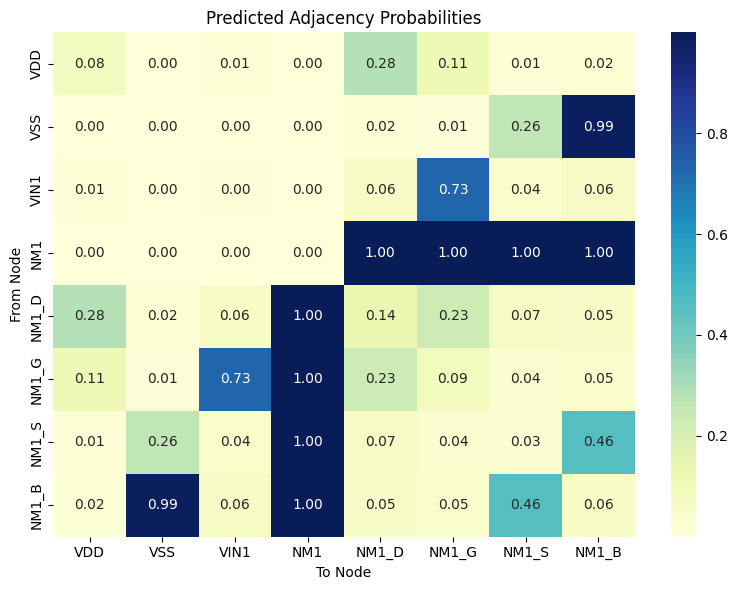

In [12]:
ex_index = 0
sample_input = circuits.component_lists[ex_index]
sample_indices = circuits.component_indices[ex_index]
actual_matrix = circuits.graphs[ex_index]

partial_adj = [
    [0,0,0,0,1,1,0,0],
    [0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0],
    [1,0,0,0,0,0,0,0],
    [1,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0]
]

evaluate_partial_matrix(model, sample_indices, partial_adj=0, circuits=circuits, actual_matrix=actual_matrix)


In [ ]:
print(circuits.vocab_to_index(circuits.component_lists[0][0]))

TypeError: 'dict' object is not callable

In [ ]:
def load_model_from_checkpoint(checkpoint_path, model_class, device='cuda'):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Extract saved hyperparameters
    vocab_size = checkpoint['vocab_size']
    embedding_dim = checkpoint['embedding_dim']
    hidden_dim = checkpoint['hidden_dim']
    num_heads = checkpoint['num_heads']
    num_layers = checkpoint['num_layers']
    dropout = checkpoint['dropout']
    learning_rate = checkpoint['learning_rate']

    # Initialize model
    model = model_class(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    # Load state dict
    model.load_state_dict(checkpoint['model_state_dict'])

    # Initialize optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch'] + 1  # Resume from next epoch

    print(f"✅ Loaded model from epoch {checkpoint['epoch']} at: {checkpoint_path}")

    return model, optimizer, start_epoch


✅ Loaded model from epoch 60 at: D:/MY FILES/Projects/circuits_gen/Moduler_version/Saves/TtoGmodel_epoch60_20250418_000017.pth

🔍 Predicted Probabilities:
0.01 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 1.00 0.00 0.00 0.00 1.00 1.00 0.00 0.00 0.00 1.00 1.00 0.00 0.00 0.00 1.00 1.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 1.00 1.00 0.00 0.00 0.00 1.00 1.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 1.00 1.00 0.00 0.00 0.00 1.00 1.00 0.00 0.00 0.00 1.00 1.00 0.00 0.00 0.00 1.00 1.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 

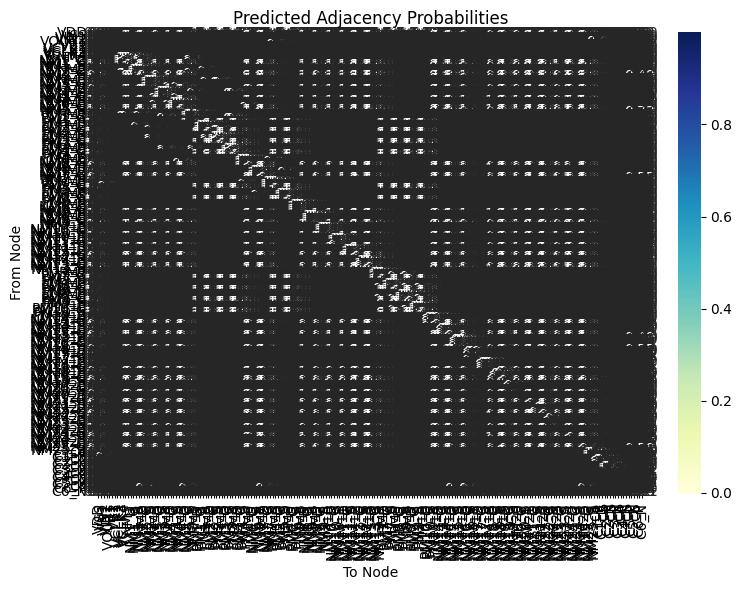

In [ ]:
# Example usage

# 1. Path to saved checkpoint
file_name = "TtoGmodel_epoch60_20250418_000017.pth"
checkpoint_path = 'D:/MY FILES/Projects/circuits_gen/Moduler_version/Saves/' + file_name # Replace with your file

# 2. Load the model and optimizer
model, optimizer, start_epoch = load_model_from_checkpoint(checkpoint_path, TextToGraphTransformer)


ex_index = 3300
sample_input = circuits.component_lists[ex_index]
sample_indices = circuits.component_indices[ex_index]
actual_matrix = circuits.graphs[ex_index]
"""
partial_adj = [
    [0,0,0,0,1,1,0,0],
    [0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,0],
    [1,0,0,0,0,0,0,0],
    [1,0,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0],
    [0,0,0,0,0,0,0,0]
]
"""
evaluate_partial_matrix(model, sample_indices, partial_adj=0, circuits=circuits, actual_matrix=actual_matrix)

